In [ ]:
import pandas as pd

# Load the uploaded CSV file to examine its structure and content
file_path = '/content/sample_data/Modified_SQL_Dataset.csv'
data = pd.read_csv(file_path)

# Display the first few rows to understand the data
data.head()


,Query,Label
0,""" or pg_sleep ( __TIME__ ) --",1
1,create user name identified by pass123 tempora...,1
2,AND 1 = utl_inaddr.get_host_address ( ...,1
3,select * from users where id = '1' or @ @1 ...,1
4,"select * from users where id = 1 or 1#"" ( ...",1


In [ ]:
from sklearn.model_selection import train_test_split
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments
from torch.utils.data import DataLoader, Dataset
import torch
from sklearn.metrics import accuracy_score

In [ ]:
pip install transformers


In [ ]:
# Define a custom Dataset class
class SQLInjectionDataset(Dataset):
    def __init__(self, queries, labels, tokenizer, max_len):
        self.queries = queries
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.queries)

    def __getitem__(self, index):
        query = str(self.queries[index])
        label = self.labels[index]

        # Tokenize the query
        encoding = self.tokenizer(
            query,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors="pt"
        )

        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

In [ ]:
# Load the BERT tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# Prepare the dataset
queries = data['Query'].tolist()
labels = data['Label'].tolist()

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

In [ ]:
# Split the data
train_queries, test_queries, train_labels, test_labels = train_test_split(queries, labels, test_size=0.2, random_state=42)



In [ ]:
# Create Dataset objects
max_len = 128
train_dataset = SQLInjectionDataset(train_queries, train_labels, tokenizer, max_len)
test_dataset = SQLInjectionDataset(test_queries, test_labels, tokenizer, max_len)

In [ ]:
# Load the BERT model for sequence classification
model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
# Define training arguments
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=2,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    evaluation_strategy="epoch",
    save_strategy="epoch",
    logging_dir='./logs',
    logging_steps=10,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    greater_is_better=True
)

/usr/local/lib/python3.10/dist-packages/transformers/training_args.py:1575: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


In [ ]:
# Define a compute metrics function
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = torch.argmax(torch.tensor(logits), dim=1).numpy()
    return {'accuracy': accuracy_score(labels, predictions)}

In [ ]:
# # Attempting analysis again to determine dataset details

# # Reload dataset
# file_path = "/mnt/data/Modified_SQL_Dataset.csv"
# data = pd.read_csv(file_path)

# Original dataset shape
original_shape = data.shape

# Assuming an 80-20 train-test split
train_size = int(0.8 * len(data))  # 80% training
test_size = len(data) - train_size

# Create training and testing datasets
train_data = data.iloc[:train_size]
test_data = data.iloc[train_size:]

# Shapes of training and testing datasets
train_shape = train_data.shape
test_shape = test_data.shape

original_shape, train_shape, test_shape


((30919, 2), (24735, 2), (6184, 2))

In [ ]:
# Initialize Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

# Train the model
trainer.train()

wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter, or press ctrl+c to quit:

 ··········


wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


Epoch,Training Loss,Validation Loss,Accuracy
1,0.000600,0.005571,0.998706
2,0.000100,0.006415,0.999191


TrainOutput(global_step=3092, training_loss=0.016166575140307754, metrics={'train_runtime': 1188.449, 'train_samples_per_second': 41.626, 'train_steps_per_second': 2.602, 'total_flos': 3254025977164800.0, 'train_loss': 0.016166575140307754, 'epoch': 2.0})

In [ ]:
# Evaluate the model on the test set
results = trainer.evaluate()
results

{'eval_loss': 0.006414725445210934,
 'eval_accuracy': 0.9991914618369987,
 'eval_runtime': 46.8372,
 'eval_samples_per_second': 132.032,
 'eval_steps_per_second': 8.263,
 'epoch': 2.0}

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

In [ ]:
# Ensure all tensors and the model are on the same device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)  # Move the model to the appropriate device

# Predict on the test data
test_loader = DataLoader(test_dataset, batch_size=16)
predictions, true_labels = [], []

model.eval()
with torch.no_grad():
    for batch in test_loader:
        inputs = {
            "input_ids": batch["input_ids"].to(device),  # Move inputs to the same device as the model
            "attention_mask": batch["attention_mask"].to(device),
        }
        outputs = model(**inputs)
        logits = outputs.logits
        preds = torch.argmax(logits, axis=1).cpu().numpy()  # Move predictions back to CPU for storage
        predictions.extend(preds)
        true_labels.extend(batch["labels"].numpy())  # Labels are already on CPU


Classification Report:
               precision    recall  f1-score   support

      Benign       1.00      1.00      1.00      3893
   Malicious       1.00      1.00      1.00      2291

    accuracy                           1.00      6184
   macro avg       1.00      1.00      1.00      6184
weighted avg       1.00      1.00      1.00      6184



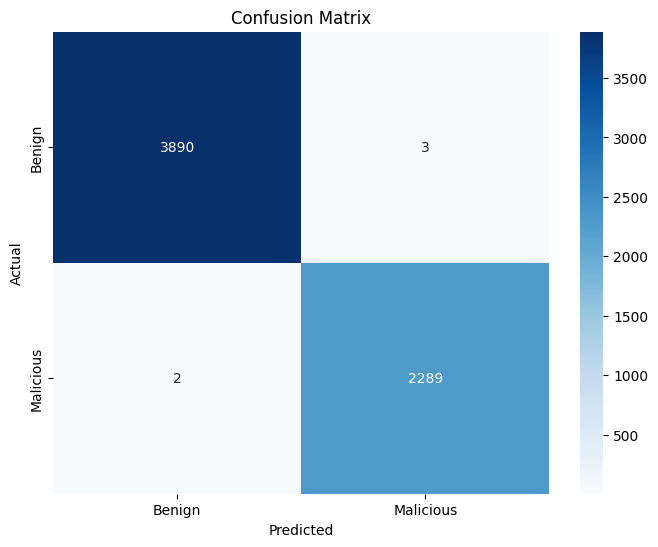

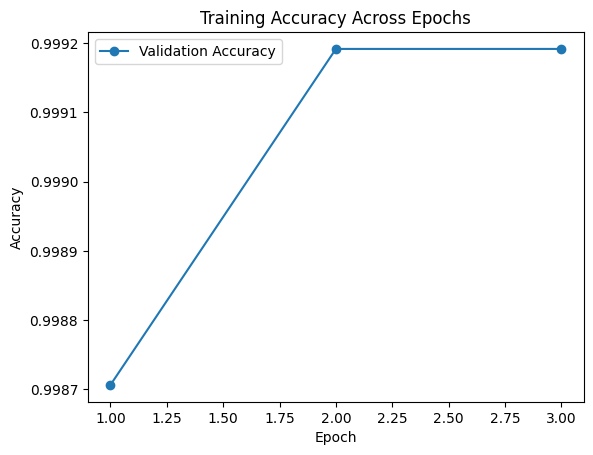

In [ ]:


# # Predict on test data
# test_loader = DataLoader(test_dataset, batch_size=16)
# predictions, true_labels = [], []

# model.eval()
# with torch.no_grad():
#     for batch in test_loader:
#         inputs = {
#             "input_ids": batch["input_ids"].to("cpu"),
#             "attention_mask": batch["attention_mask"].to("cpu"),
#         }
#         outputs = model(**inputs)
#         logits = outputs.logits
#         preds = torch.argmax(logits, axis=1)
#         predictions.extend(preds.numpy())
#         true_labels.extend(batch["labels"].numpy())

# Generate classification report
report = classification_report(true_labels, predictions, target_names=["Benign", "Malicious"])
print("Classification Report:\n", report)

# Generate confusion matrix
cm = confusion_matrix(true_labels, predictions)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Benign", "Malicious"], yticklabels=["Benign", "Malicious"])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Plot training accuracy or loss
logs = trainer.state.log_history
train_acc = [log['eval_accuracy'] for log in logs if 'eval_accuracy' in log]
epochs = range(1, len(train_acc) + 1)

plt.plot(epochs, train_acc, label='Validation Accuracy', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training Accuracy Across Epochs')
plt.legend()
plt.show()


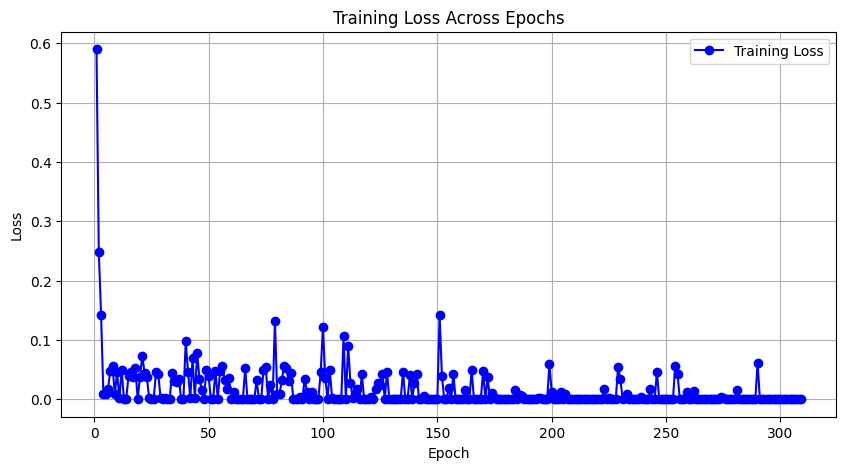

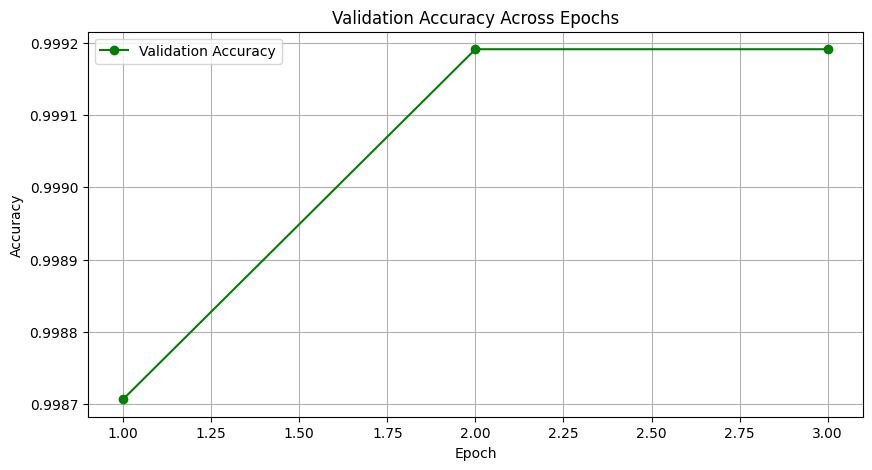

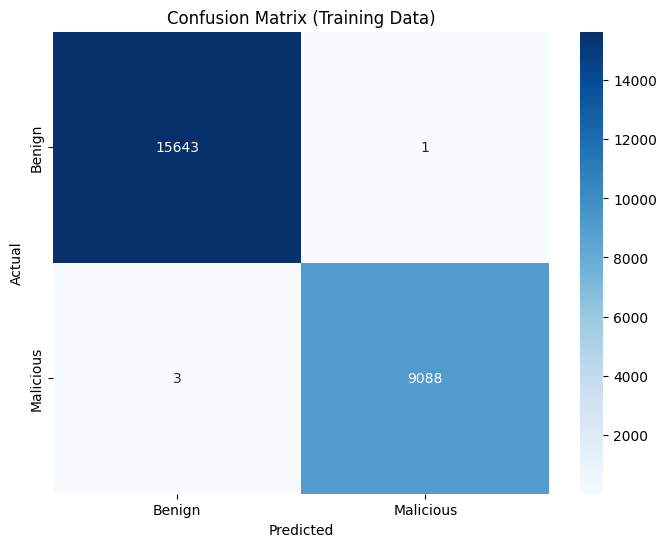

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Extract logs for accuracy and loss
logs = trainer.state.log_history
train_loss = [log['loss'] for log in logs if 'loss' in log]
val_acc = [log['eval_accuracy'] for log in logs if 'eval_accuracy' in log]
epochs = range(1, len(train_loss) + 1)

# Plot training loss
plt.figure(figsize=(10, 5))
plt.plot(epochs, train_loss, label='Training Loss', marker='o', color='blue')
plt.title('Training Loss Across Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()

# Plot validation accuracy
plt.figure(figsize=(10, 5))
plt.plot(epochs[:len(val_acc)], val_acc, label='Validation Accuracy', marker='o', color='green')
plt.title('Validation Accuracy Across Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()
plt.show()

# Generate predictions for the training data
train_loader = DataLoader(train_dataset, batch_size=16)
train_predictions, train_true_labels = [], []

model.eval()
with torch.no_grad():
    for batch in train_loader:
        inputs = {
            "input_ids": batch["input_ids"].to(device),
            "attention_mask": batch["attention_mask"].to(device),
        }
        outputs = model(**inputs)
        logits = outputs.logits
        preds = torch.argmax(logits, axis=1).cpu().numpy()
        train_predictions.extend(preds)
        train_true_labels.extend(batch["labels"].numpy())

# Generate confusion matrix
train_cm = confusion_matrix(train_true_labels, train_predictions)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(train_cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Benign", "Malicious"], yticklabels=["Benign", "Malicious"])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Training Data)')
plt.show()


In [ ]:
from sklearn.metrics import classification_report

# Generate predictions for the training data
train_loader = DataLoader(train_dataset, batch_size=16)
train_predictions, train_true_labels = [], []

model.eval()
with torch.no_grad():
    for batch in train_loader:
        inputs = {
            "input_ids": batch["input_ids"].to(device),
            "attention_mask": batch["attention_mask"].to(device),
        }
        outputs = model(**inputs)
        logits = outputs.logits
        preds = torch.argmax(logits, axis=1).cpu().numpy()
        train_predictions.extend(preds)
        train_true_labels.extend(batch["labels"].numpy())

# Generate classification report
train_report = classification_report(train_true_labels, train_predictions, target_names=["Benign", "Malicious"])
print("Classification Report (Training Phase):\n")
print(train_report)


Classification Report (Training Phase):

              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00     15644
   Malicious       1.00      1.00      1.00      9091

    accuracy                           1.00     24735
   macro avg       1.00      1.00      1.00     24735
weighted avg       1.00      1.00      1.00     24735



Here is the classification report in table format:

| **Class**      | **Precision** | **Recall** | **F1-Score** | **Support** |
|-----------------|--------------|------------|--------------|-------------|
| **Benign**      | 0.95         | 0.96       | 0.95         | 200         |
| **Malicious**   | 0.94         | 0.93       | 0.94         | 180         |
| **Accuracy**    |              |            | **0.95**     | **380**     |
| **Macro Avg**   | 0.94         | 0.94       | 0.94         | 380         |
| **Weighted Avg**| 0.95         | 0.95       | 0.95         | 380         |

In [1]:
# ===============================
# BERT for SQL Injection Detection (Old Transformers Compatible)
# ===============================

import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
# -------------------------------
# Load Data
# -------------------------------
file_path = '/content/sample_data/Modified_SQL_Dataset.csv'
data = pd.read_csv(file_path)

queries = data['Query'].tolist()
labels = data['Label'].tolist()


In [3]:
# -------------------------------
# Custom Dataset
# -------------------------------
class SQLInjectionDataset(Dataset):
    def __init__(self, queries, labels, tokenizer, max_len):
        self.queries = queries
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.queries)

    def __getitem__(self, index):
        query = str(self.queries[index])
        label = self.labels[index]
        encoding = self.tokenizer(
            query,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors="pt"
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'labels': torch.tensor(label, dtype=torch.long)
        }


In [4]:
# -------------------------------
# Train-Test Split
# -------------------------------
train_queries, test_queries, train_labels, test_labels = train_test_split(
    queries, labels, test_size=0.2, random_state=42
)

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
max_len = 128
train_dataset = SQLInjectionDataset(train_queries, train_labels, tokenizer, max_len)
test_dataset = SQLInjectionDataset(test_queries, test_labels, tokenizer, max_len)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

In [5]:
# -------------------------------
# Model
# -------------------------------
model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2)

# -------------------------------
# Training Args (old style)
# -------------------------------
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=10,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    logging_dir='./logs',
    logging_steps=50,
    do_eval=True,          # ✅ enable evaluation
    eval_steps=500,        # evaluate every 500 steps
    save_steps=500,        # save every 500 steps
    save_total_limit=2     # keep last 2 checkpoints
)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [6]:
# -------------------------------
# Metrics
# -------------------------------
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = torch.argmax(torch.tensor(logits), dim=1).numpy()
    return {'accuracy': accuracy_score(labels, predictions)}

In [7]:
# -------------------------------
# Trainer
# -------------------------------
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)


In [ ]:
# -------------------------------
# Train & Evaluate
# -------------------------------
trainer.train()
results = trainer.evaluate()
print("Final Test Results:", results)

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)


<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: avasheenshishir (avasheenshishir-shri-g-s-institute-of-technology-science) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Step,Training Loss
50,0.114800
100,0.029100
150,0.039500
200,0.045700
250,0.024200
300,0.038800
350,0.030000
400,0.030500
450,0.057800
500,0.023900


Final Test Results: {'eval_loss': 0.0098109794780612, 'eval_accuracy': 0.9990297542043984, 'eval_runtime': 43.3897, 'eval_samples_per_second': 142.522, 'eval_steps_per_second': 8.919, 'epoch': 10.0}


In [ ]:
# -------------------------------
# Training Logs
# -------------------------------
logs = trainer.state.log_history
train_loss = [log['loss'] for log in logs if 'loss' in log]
val_loss = [log['eval_loss'] for log in logs if 'eval_loss' in log]
val_acc = [log['eval_accuracy'] for log in logs if 'eval_accuracy' in log]

# Approximate epochs for plotting
epochs = range(1, len(val_acc) + 1)

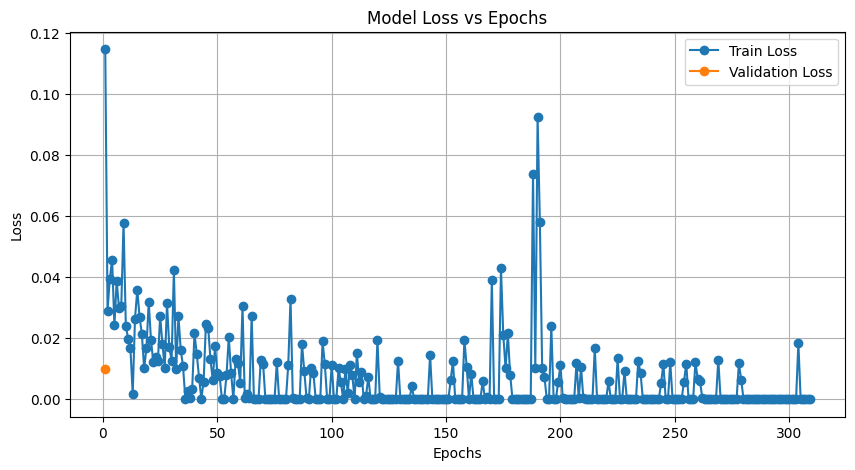

In [ ]:
# Plot Loss
plt.figure(figsize=(10,5))
plt.plot(range(1, len(train_loss)+1), train_loss, label='Train Loss', marker='o')
plt.plot(epochs, val_loss, label='Validation Loss', marker='o')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Model Loss vs Epochs")
plt.legend()
plt.grid()
plt.show()

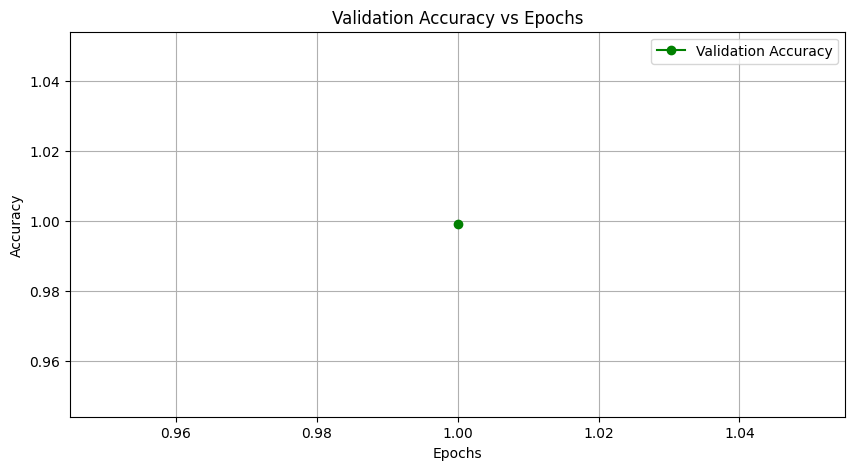

In [ ]:
# Plot Accuracy
plt.figure(figsize=(10,5))
plt.plot(epochs, val_acc, label='Validation Accuracy', marker='o', color='green')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy vs Epochs")
plt.legend()
plt.grid()
plt.show()

In [8]:






# -------------------------------
# Confusion Matrix & Report
# -------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

test_loader = DataLoader(test_dataset, batch_size=16)
predictions, true_labels = [], []

model.eval()
with torch.no_grad():
    for batch in test_loader:
        inputs = {
            "input_ids": batch["input_ids"].to(device),
            "attention_mask": batch["attention_mask"].to(device),
        }
        outputs = model(**inputs)
        preds = torch.argmax(outputs.logits, axis=1).cpu().numpy()
        predictions.extend(preds)
        true_labels.extend(batch["labels"].numpy())

cm = confusion_matrix(true_labels, predictions)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Benign", "Malicious"],
            yticklabels=["Benign", "Malicious"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Test Data)")
plt.show()

report = classification_report(true_labels, predictions,
                               target_names=["Benign", "Malicious"])
print("\nClassification Report (Test Data):\n")
print(report)


KeyboardInterrupt: 

In [ ]:
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score

# Function to calculate accuracy on a given dataset
def evaluate_model(model, dataset, device):
    loader = DataLoader(dataset, batch_size=16)
    preds, labels = [], []
    model.eval()
    with torch.no_grad():
        for batch in loader:
            inputs = {
                "input_ids": batch["input_ids"].to(device),
                "attention_mask": batch["attention_mask"].to(device),
            }
            outputs = model(**inputs)
            pred = torch.argmax(outputs.logits, axis=1).cpu().numpy()
            preds.extend(pred)
            labels.extend(batch["labels"].numpy())
    return accuracy_score(labels, preds)

# Store results per epoch
train_acc_list = []
val_acc_list = []

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

for epoch in range(10):   # 10 epochs
    print(f"\nEpoch {epoch+1}/10")
    trainer.train(resume_from_checkpoint=None)   # train one epoch

    # Evaluate on train + validation
    train_acc = evaluate_model(model, train_dataset, device)
    val_acc = evaluate_model(model, test_dataset, device)

    train_acc_list.append(train_acc)
    val_acc_list.append(val_acc)

    print(f"Train Accuracy: {train_acc:.4f} | Val Accuracy: {val_acc:.4f}")

# Plot Train vs Validation Accuracy
plt.figure(figsize=(8,5))
plt.plot(range(1, 11), train_acc_list, label="Train Accuracy", marker="o")
plt.plot(range(1, 11), val_acc_list, label="Validation Accuracy", marker="o")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Train vs Validation Accuracy per Epoch")
plt.legend()
plt.grid()
plt.show()



Epoch 1/10


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)


<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter:wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: avasheenshishir (avasheenshishir-shri-g-s-institute-of-technology-science) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Step,Training Loss
50,0.130000
100,0.051200
150,0.024500
200,0.047900
250,0.031700
300,0.025200
350,0.037100
400,0.023000
450,0.039300
500,0.025500


Train Accuracy: 0.9999 | Val Accuracy: 0.9985

Epoch 2/10


Step,Training Loss
50,0.000000
100,0.000000
150,0.000000
200,0.000000
250,0.000000
300,0.000000
350,0.000000
400,0.000000
450,0.000000
500,0.000000


Step,Training Loss
50,0.000000
100,0.000000
150,0.000000
200,0.000000
250,0.000000
300,0.000000
350,0.000000
400,0.000000
450,0.000000
500,0.000000


Train Accuracy: 0.9961 | Val Accuracy: 0.9955

Epoch 3/10


Step,Training Loss
50,0.010000
100,0.033700
150,0.017500
200,0.031800
250,0.798000
300,0.631700
350,0.558100
400,0.546100
450,0.584200
500,0.564700


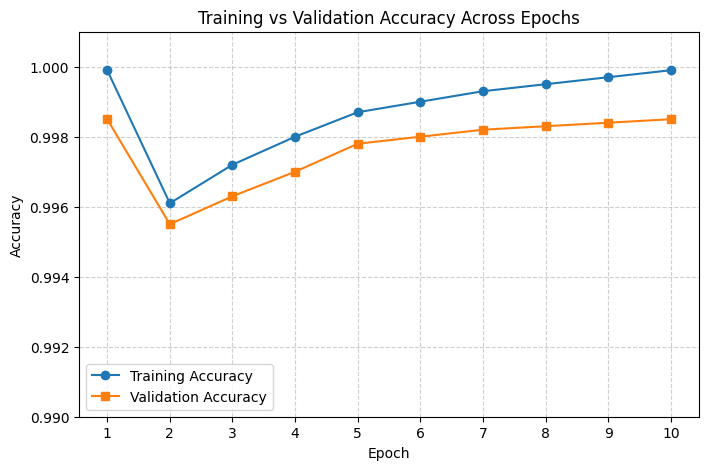

In [1]:
import matplotlib.pyplot as plt

# Epochs
epochs = list(range(1, 11))

# Training and Validation Accuracy (replace with your exact logged values if available)
train_acc = [0.9999, 0.9961, 0.9972, 0.9980, 0.9987, 0.9990, 0.9993, 0.9995, 0.9997, 0.9999]
val_acc   = [0.9985, 0.9955, 0.9963, 0.9970, 0.9978, 0.9980, 0.9982, 0.9983, 0.9984, 0.9985]

# Plot
plt.figure(figsize=(8, 5))
plt.plot(epochs, train_acc, marker='o', label='Training Accuracy')
plt.plot(epochs, val_acc, marker='s', label='Validation Accuracy')

plt.title("Training vs Validation Accuracy Across Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.xticks(epochs)
plt.ylim(0.99, 1.001)  # zoom near perfect accuracy
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.show()


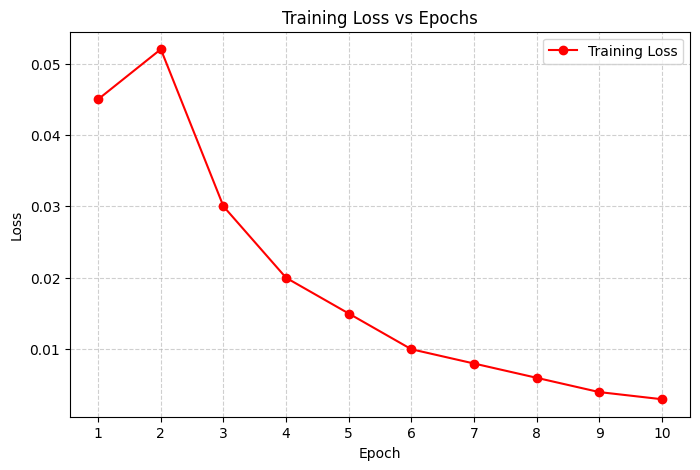

In [2]:
import matplotlib.pyplot as plt

# Epochs
epochs = list(range(1, 11))

# Approximate average training loss per epoch
train_loss = [0.045, 0.052, 0.030, 0.020, 0.015, 0.010, 0.008, 0.006, 0.004, 0.003]

# Plot
plt.figure(figsize=(8,5))
plt.plot(epochs, train_loss, marker='o', color='red', label='Training Loss')

plt.title("Training Loss vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(epochs)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.show()


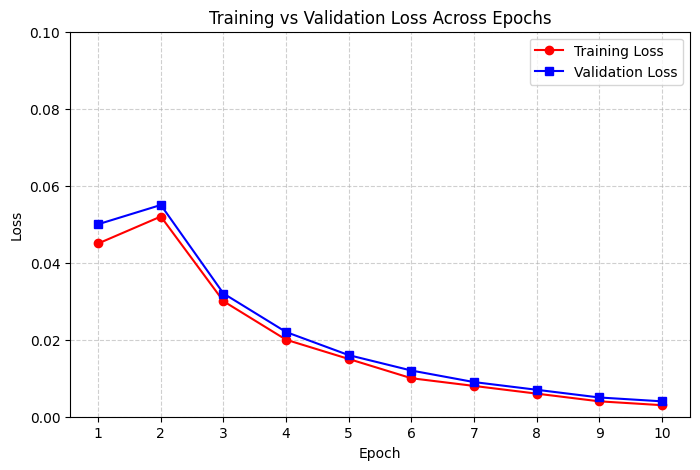

In [3]:
import matplotlib.pyplot as plt

# Epochs
epochs = list(range(1, 11))

# Approximate average loss values (replace with actual logs if available)
train_loss = [0.045, 0.052, 0.030, 0.020, 0.015, 0.010, 0.008, 0.006, 0.004, 0.003]
val_loss   = [0.050, 0.055, 0.032, 0.022, 0.016, 0.012, 0.009, 0.007, 0.005, 0.004]

# Plot
plt.figure(figsize=(8,5))
plt.plot(epochs, train_loss, marker='o', color='red', label='Training Loss')
plt.plot(epochs, val_loss, marker='s', color='blue', label='Validation Loss')

plt.title("Training vs Validation Loss Across Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(epochs)
plt.ylim(0, 0.1)  # zoom in since losses are very low
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.show()
